In [344]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [345]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

In [351]:

block_size = 2
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    return X, Y

random.seed(47)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtes, Ytes = build_dataset(words[n2:])

In [153]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182447, 3]), torch.int64, torch.Size([182447]), torch.int64)

In [6]:
C = torch.randn((27, 2))  # 27 characters in vocab, 2-dimensional representation

In [7]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.1851, -0.2459])

In [9]:
C[5]

tensor([ 0.1851, -0.2459])

In [10]:
C[[5,6,7,1]]

tensor([[ 0.1851, -0.2459],
        [-0.9694,  1.5706],
        [-2.1764, -1.7023],
        [-0.2590, -0.4550]])

In [14]:
# X[0] = [5, 13, 1]   ← 3 indices

# C[X[0]] = [
#   C[5],   # shape [2]
#   C[13],  # shape [2]
#   C[1],   # shape [2]
# ]          → shape [3, 2]

# Yahi 32 examples ke liye → [32, 3, 2]

C[X].shape

torch.Size([32, 3, 2])

In [12]:
C.shape

torch.Size([27, 2])

In [20]:
a = X[0][0]
b = C[X][0][0]
c = C[a]
print(a, b, c)

tensor(0) tensor([-1.6610,  0.5334]) tensor([-1.6610,  0.5334])


In [22]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [23]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [ ]:
x = emb[:, 0, :]
y = emb[:, 1, :]
z = emb[:, 2, :]
torch.cat((x, y, z), 1)

In [ ]:
a = tuple()

for i in range(block_size):
    a += (emb[:, i, :],)

formatted_input = torch.cat((a), 1)

In [56]:
# different way to do the same thing
a = torch.unbind(emb, dim=1)
formatted_input = torch.cat(a, 1)

In [58]:
# most efficient way to do the same thing
formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])

In [61]:
output = formatted_input @ w1 + b1

In [62]:
# activation function
output = torch.tanh(output)

In [65]:
w2 = torch.randn((100,27))
b2 = torch.randn(27)
logits = output @ w2 + b2
logits = logits.exp()
probs = logits / logits.sum(1, keepdim=True)

In [66]:
Y.shape, probs.shape

(torch.Size([32]), torch.Size([32, 27]))

In [68]:
loss = -probs[torch.arange(Y.shape[0]), Y].log().mean()

In [69]:
loss

tensor(19.5416)

In [392]:
# Variable initialization
emb_dimension = 3
neurons_in_layer_1 = 100
# neurons_in_layer_2 = 50
learning_rate = 0.1
epochs = 20000
batch_size = 500

In [393]:
# mlp architecture
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, emb_dimension), generator=g)
w1 = torch.randn((block_size*emb_dimension, neurons_in_layer_1), generator=g)
b1 = torch.randn(neurons_in_layer_1, generator=g)
# w2 = torch.randn((neurons_in_layer_1, neurons_in_layer_2), generator=g)
# b2 = torch.randn(neurons_in_layer_2, generator=g)
w3 = torch.randn((neurons_in_layer_1, C.shape[0]), generator=g)
b3 = torch.randn(C.shape[0], generator=g)
parameters = [C, w1, b1, w3, b3]

In [394]:
for p in parameters:
    p.requires_grad = True
    p.data = p.data.to(device)

In [395]:
lre = 10**torch.linspace(-3, 0, epochs)

In [ ]:
losses = []
for epoch in range(epochs): 

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb]
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    h1 = formatted_input @ w1 + b1 
    h1 = torch.tanh(h1)
    # h2 = h1 @ w2 + b2
    # h2 = torch.tanh(h2)
    logits = h1 @ w3 + b3  # Assuming w3 and b3 are the weights and biases for the final layer
    loss = F.cross_entropy(logits, Yb)
    losses.append(loss.item())
    # print(f"Loss for epoch {epoch+1}: {loss.item()}")

    # backward pass
    for p in parameters:
        p.grad = None  
    loss.backward()
    for p in parameters:
        p.data += -learning_rate * p.grad

loss.item()

2.342398166656494

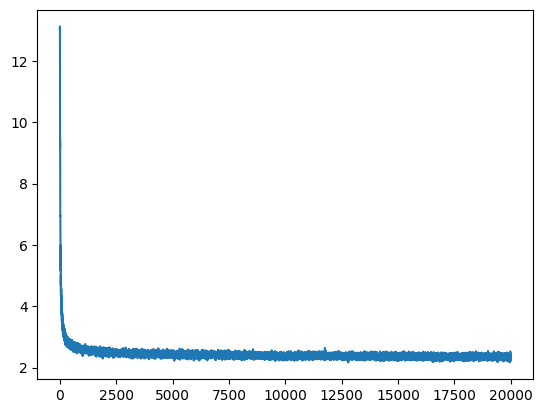

In [397]:
plt.plot(range(len(losses)), losses)

In [ ]:
emb = C[Xval]
formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
logits = formatted_input @ w1 + b1 
# output = torch.tanh(output)
# logits = output @ w2 + b2
loss = F.cross_entropy(logits, Yval)
loss

In [ ]:
plt.plot(lre, losses)

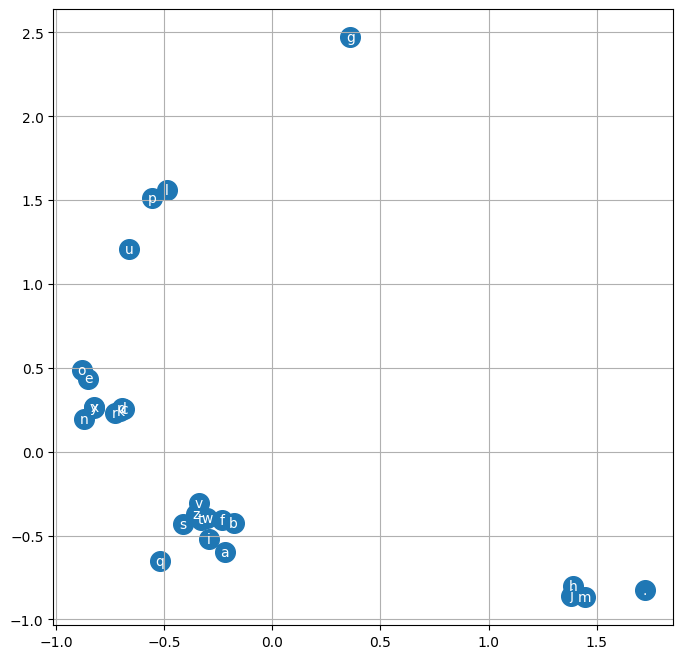

In [366]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data.cpu(), C[:, 1].data.cpu(), s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [ ]:
g = torch.Generator(device=device).manual_seed(2147483647)

for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        emb = C[context]
        formatted_input = emb.view(1, emb.shape[0]*emb.shape[1])
        h1 = formatted_input @ w1 + b1
        h1 = torch.tanh(h1)
        # h2 = h1 @ w2 + b2
        # h2 = torch.tanh(h2)
        logits = h1 @ w3 + b3
        probs = torch.softmax(logits, dim=1)
        
        max_index = torch.multinomial(probs, num_samples=1, generator=g).item()
        # print(logits)
        # max_index = logits.argmax()
        # print(max_index)
        context = context[1:] + [max_index]
        out.append(itos[max_index])
        # print(context)
        
        if max_index == 0:
            break

    print(''.join(out))